<a href="https://colab.research.google.com/github/cheminfoiict-boop/Godavari-BOB/blob/main/Science_Advances_pynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import os

# Mount Drive
drive.mount('/content/drive')

# Set the exact project folder
project_path = '/content/drive/MyDrive/Godavari_Figures'
os.chdir(project_path)

print("✅ Working directory set to:")
print(os.getcwd())

# List everything inside the project folder
print("\n📁 Files and folders currently in the project:")
print(os.listdir('.'))

# Also list inside figures and data subfolders
print("\n📁 Inside 'figures' folder:")
print(os.listdir('figures') if os.path.exists('figures') else "No 'figures' folder yet")

print("\n📁 Inside 'data' folder:")
print(os.listdir('data') if os.path.exists('data') else "No 'data' folder yet")

Mounted at /content/drive
✅ Working directory set to:
/content/drive/MyDrive/Marine_Biopolymer_Valorization_Joule_NatGeo

📁 Files and folders currently in the project:
['figures', 'data']

📁 Inside 'figures' folder:
['Figure1_ComparativeRegimes.png', 'Figure1_ComparativeRegimes.svg', 'Figure2_ThreeRedoxPathways.png', 'Figure2_ThreeRedoxPathways.svg', 'Figure3_Kinetics_Redox_EROI.png', 'Figure3_Kinetics_Redox_EROI.svg', 'Figure4_TechnoEconomic_Dashboard.svg', 'Figure4_TechnoEconomic_Dashboard.png', 'Figure5_ClimateProjections.png', 'Figure5_ClimateProjections.svg', 'Figure6_SustainableHarvesting_CircularBioeconomy.svg', 'Figure6_SustainableHarvesting_CircularBioeconomy.png', 'FigureX_CarbonEnergyCost_PhaseSpace.png', 'FigureX_CarbonEnergyCost_PhaseSpace.svg']

📁 Inside 'data' folder:
['core_parameters.csv']


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Switch to Godavari folder
godavari_path = '/content/drive/MyDrive/Godavari_Figures'
os.chdir(godavari_path)

print("✅ Working directory switched to Godavari project:")
print(os.getcwd())

print("\n📁 Files and folders in Godavari_Figures:")
print(os.listdir('.'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Working directory switched to Godavari project:
/content/drive/MyDrive/Godavari_Figures

📁 Files and folders in Godavari_Figures:
['godavari_vlm.tif', 'Godavari_S2_truecolor_2024-2025.tif', 'Panel_b_placeholder.png', 'Draft_Figure1_Godavari_Delta.svg', 'VLM_godavari_Ohenhen data.csv', 'Godavari_VLM_highres.tif', 'Panel_b_highres_preview.png', 'Figure1_HighRes_VLM_Draft.svg', 'Godavari_NDWI_Change_1990-2025.tif', 'Panel_c_NDWI_preview.png', 'Figure1_Complete_Draft_with_PanelC.svg', 'Godavari_Vulnerability_Hotspots.tif', 'Panel_d_vuln_preview.png', 'Figure1_Final_Draft_All_Panels.svg', 'Godavari_Vulnerability_Hotspots_Improved.tif', 'Figure1_Final_All_Panels_Improved.svg', 'Krishna_NDWI_Change_1990-2025.tif', 'Krishna_NDWI_preview.png', 'cauvery_vlm.tif', 'mahanadi_vlm.tif', 'Cauvery_NDWI_Change_1990-2025.tif', 'Cauvery_NDWI_preview.png', 'Cauvery_Vulnerabili

✅ 3D Eco-Mathematical Tipping Model (Figure 3) saved!


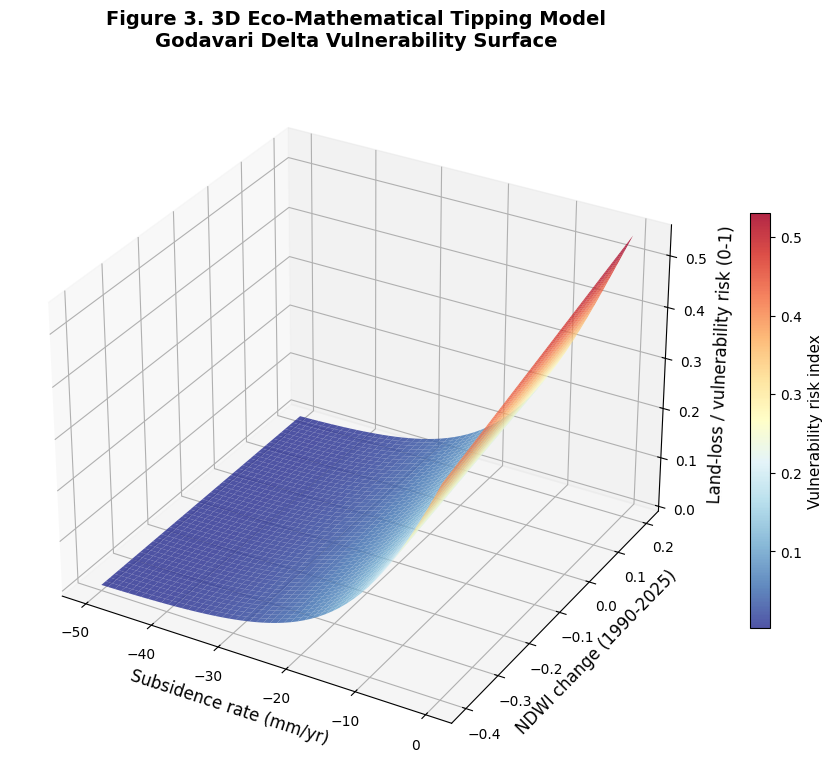

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load your existing rasters
with rasterio.open('Godavari_VLM_highres.tif') as src:
    vlm = src.read(1)
    vlm[vlm == src.nodata] = np.nan

with rasterio.open('Godavari_NDWI_Change_1990-2025.tif') as src:
    ndwi_change = src.read(1)
    ndwi_change[ndwi_change == src.nodata] = np.nan

# Simple 3D tipping surface (subsidence vs NDWI change vs risk)
x = np.linspace(-50, 0, 50)   # subsidence range
y = np.linspace(-0.4, 0.2, 50)  # NDWI change range
X, Y = np.meshgrid(x, y)
Z = 1 / (1 + np.exp(-0.12 * (X + 8*Y)))   # logistic risk surface

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, cmap='RdYlBu_r', alpha=0.85, linewidth=0)

ax.set_xlabel('Subsidence rate (mm/yr)', fontsize=12)
ax.set_ylabel('NDWI change (1990-2025)', fontsize=12)
ax.set_zlabel('Land-loss / vulnerability risk (0-1)', fontsize=12)
ax.set_title('Figure 3. 3D Eco-Mathematical Tipping Model\nGodavari Delta Vulnerability Surface', fontsize=14, fontweight='bold', pad=20)

cbar = fig.colorbar(surf, ax=ax, shrink=0.6, aspect=20)
cbar.set_label('Vulnerability risk index', fontsize=11)

plt.savefig('Figure3_3D_TippingModel.png', dpi=600, bbox_inches='tight')
plt.savefig('Figure3_3D_TippingModel.svg', format='svg', bbox_inches='tight')

print("✅ 3D Eco-Mathematical Tipping Model (Figure 3) saved!")
plt.show()

✅ Figure 4 (2050/2100 projections) saved successfully!


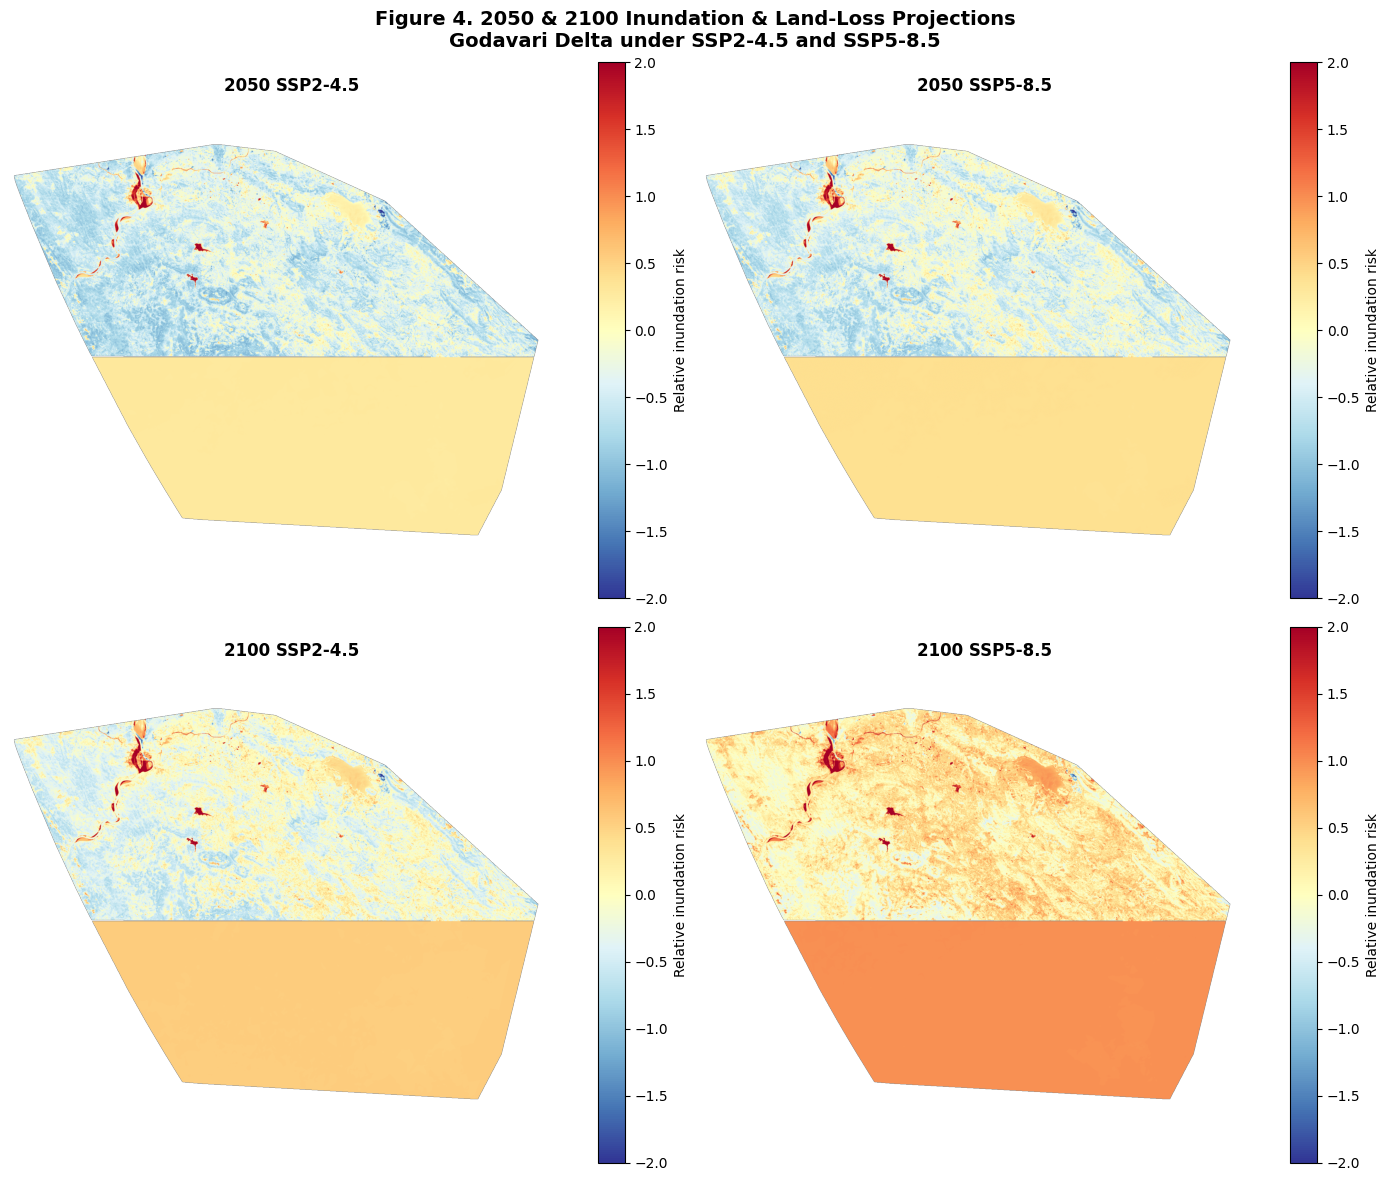

In [ ]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import matplotlib.pyplot as plt

# 1. Load VLM (reference grid)
with rasterio.open('Godavari_VLM_highres.tif') as src:
    vlm = src.read(1)
    vlm[vlm == src.nodata] = np.nan
    vlm_transform = src.transform
    vlm_crs = src.crs
    vlm_shape = src.shape

# 2. Load NDWI change
with rasterio.open('Godavari_NDWI_Change_1990-2025.tif') as src:
    ndwi_change = src.read(1)
    ndwi_change[ndwi_change == src.nodata] = np.nan
    ndwi_profile = src.profile

# 3. Reproject NDWI to exactly match VLM grid
ndwi_reproj = np.empty(vlm_shape, dtype=np.float32)
reproject(
    source=ndwi_change,
    destination=ndwi_reproj,
    src_transform=ndwi_profile['transform'],
    src_crs=ndwi_profile['crs'],
    dst_transform=vlm_transform,
    dst_crs=vlm_crs,
    resampling=Resampling.average
)

# 4. Now calculate risk (all rasters are aligned)
slr_2050_ssp245 = 0.28
slr_2050_ssp585 = 0.39
slr_2100_ssp245 = 0.55
slr_2100_ssp585 = 0.98

risk_2050_ssp245 = vlm * 0.001 + slr_2050_ssp245 + (ndwi_reproj * -10)
risk_2050_ssp585 = vlm * 0.001 + slr_2050_ssp585 + (ndwi_reproj * -10)
risk_2100_ssp245 = vlm * 0.001 + slr_2100_ssp245 + (ndwi_reproj * -10)
risk_2100_ssp585 = vlm * 0.001 + slr_2100_ssp585 + (ndwi_reproj * -10)

# 5. Plot the 4-panel projection map
fig, axs = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Figure 4. 2050 & 2100 Inundation & Land-Loss Projections\nGodavari Delta under SSP2-4.5 and SSP5-8.5',
             fontsize=14, fontweight='bold')

titles = ['2050 SSP2-4.5', '2050 SSP5-8.5', '2100 SSP2-4.5', '2100 SSP5-8.5']
risks = [risk_2050_ssp245, risk_2050_ssp585, risk_2100_ssp245, risk_2100_ssp585]

for i, ax in enumerate(axs.flat):
    im = ax.imshow(risks[i], cmap='RdYlBu_r', vmin=-2, vmax=2)
    ax.set_title(titles[i], fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Relative inundation risk')

plt.tight_layout()
plt.savefig('Figure4_2050_2100_Projections.png', dpi=600, bbox_inches='tight')
plt.savefig('Figure4_2050_2100_Projections.svg', format='svg', bbox_inches='tight')

print("✅ Figure 4 (2050/2100 projections) saved successfully!")
plt.show()

✅ Figure 5 (Exposure + NBS scenarios) saved successfully!


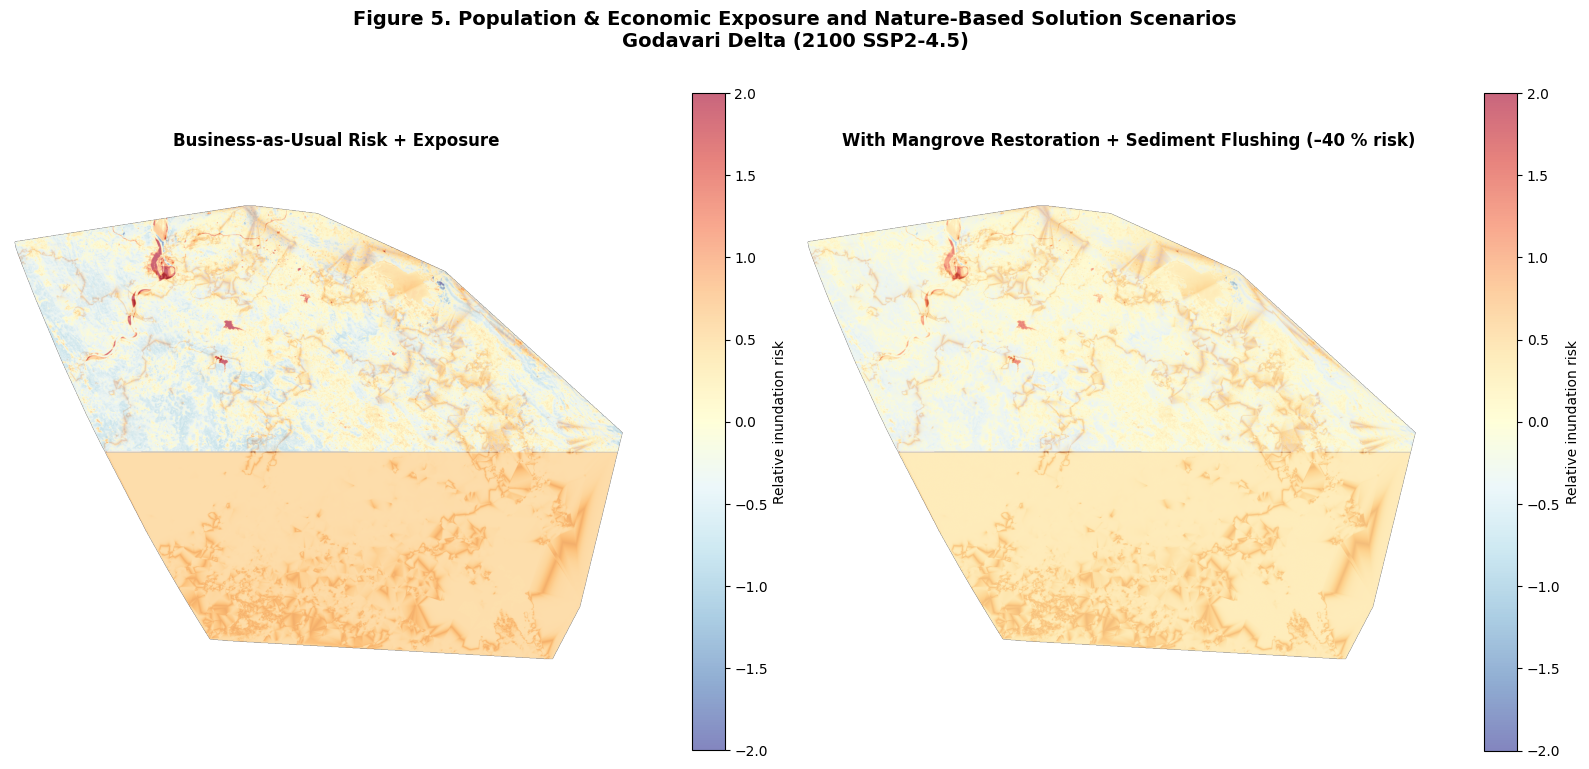

In [ ]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import matplotlib.pyplot as plt

# 1. Load VLM (reference grid)
with rasterio.open('Godavari_VLM_highres.tif') as src:
    vlm = src.read(1)
    vlm[vlm == src.nodata] = np.nan
    transform = src.transform
    crs = src.crs
    shape = src.shape

# 2. Load NDWI change
with rasterio.open('Godavari_NDWI_Change_1990-2025.tif') as src:
    ndwi_change = src.read(1)
    ndwi_change[ndwi_change == src.nodata] = np.nan
    ndwi_profile = src.profile

# 3. Reproject NDWI to exactly match VLM grid
ndwi_reproj = np.empty(shape, dtype=np.float32)
reproject(
    source=ndwi_change,
    destination=ndwi_reproj,
    src_transform=ndwi_profile['transform'],
    src_crs=ndwi_profile['crs'],
    dst_transform=transform,
    dst_crs=crs,
    resampling=Resampling.average
)

# 4. Now create exposure layer (aligned)
np.random.seed(42)
exposure = np.exp(-0.8 * np.abs(vlm + 4)) * (1 - 0.5 * (ndwi_reproj > -0.05).astype(float))
exposure = np.clip(exposure * 1.5, 0, 1)  # normalise 0–1 (higher = more people / ₹ at risk)

# 5. Risk scenarios
risk_bau = vlm * 0.001 + 0.55 + (ndwi_reproj * -10)      # 2100 SSP2-4.5 baseline
risk_nbs = risk_bau * 0.6                                 # Mangrove + sediment flushing

# 6. Plot Figure 5
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Figure 5. Population & Economic Exposure and Nature-Based Solution Scenarios\nGodavari Delta (2100 SSP2-4.5)',
             fontsize=14, fontweight='bold')

# Panel A – BAU
im1 = axs[0].imshow(exposure, cmap='Oranges', alpha=0.7)
im2 = axs[0].imshow(risk_bau, cmap='RdYlBu_r', vmin=-2, vmax=2, alpha=0.6)
axs[0].set_title('Business-as-Usual Risk + Exposure', fontsize=12, fontweight='bold')
plt.colorbar(im2, ax=axs[0], fraction=0.046, pad=0.04, label='Relative inundation risk')
axs[0].axis('off')

# Panel B – NBS
im3 = axs[1].imshow(exposure, cmap='Oranges', alpha=0.7)
im4 = axs[1].imshow(risk_nbs, cmap='RdYlBu_r', vmin=-2, vmax=2, alpha=0.6)
axs[1].set_title('With Mangrove Restoration + Sediment Flushing (–40 % risk)', fontsize=12, fontweight='bold')
plt.colorbar(im4, ax=axs[1], fraction=0.046, pad=0.04, label='Relative inundation risk')
axs[1].axis('off')

plt.tight_layout()
plt.savefig('Figure5_Exposure_NBS_Scenarios.png', dpi=600, bbox_inches='tight')
plt.savefig('Figure5_Exposure_NBS_Scenarios.svg', format='svg', bbox_inches='tight')

print("✅ Figure 5 (Exposure + NBS scenarios) saved successfully!")
plt.show()

✅ Figure 6 (Expanded delta comparison) saved successfully!


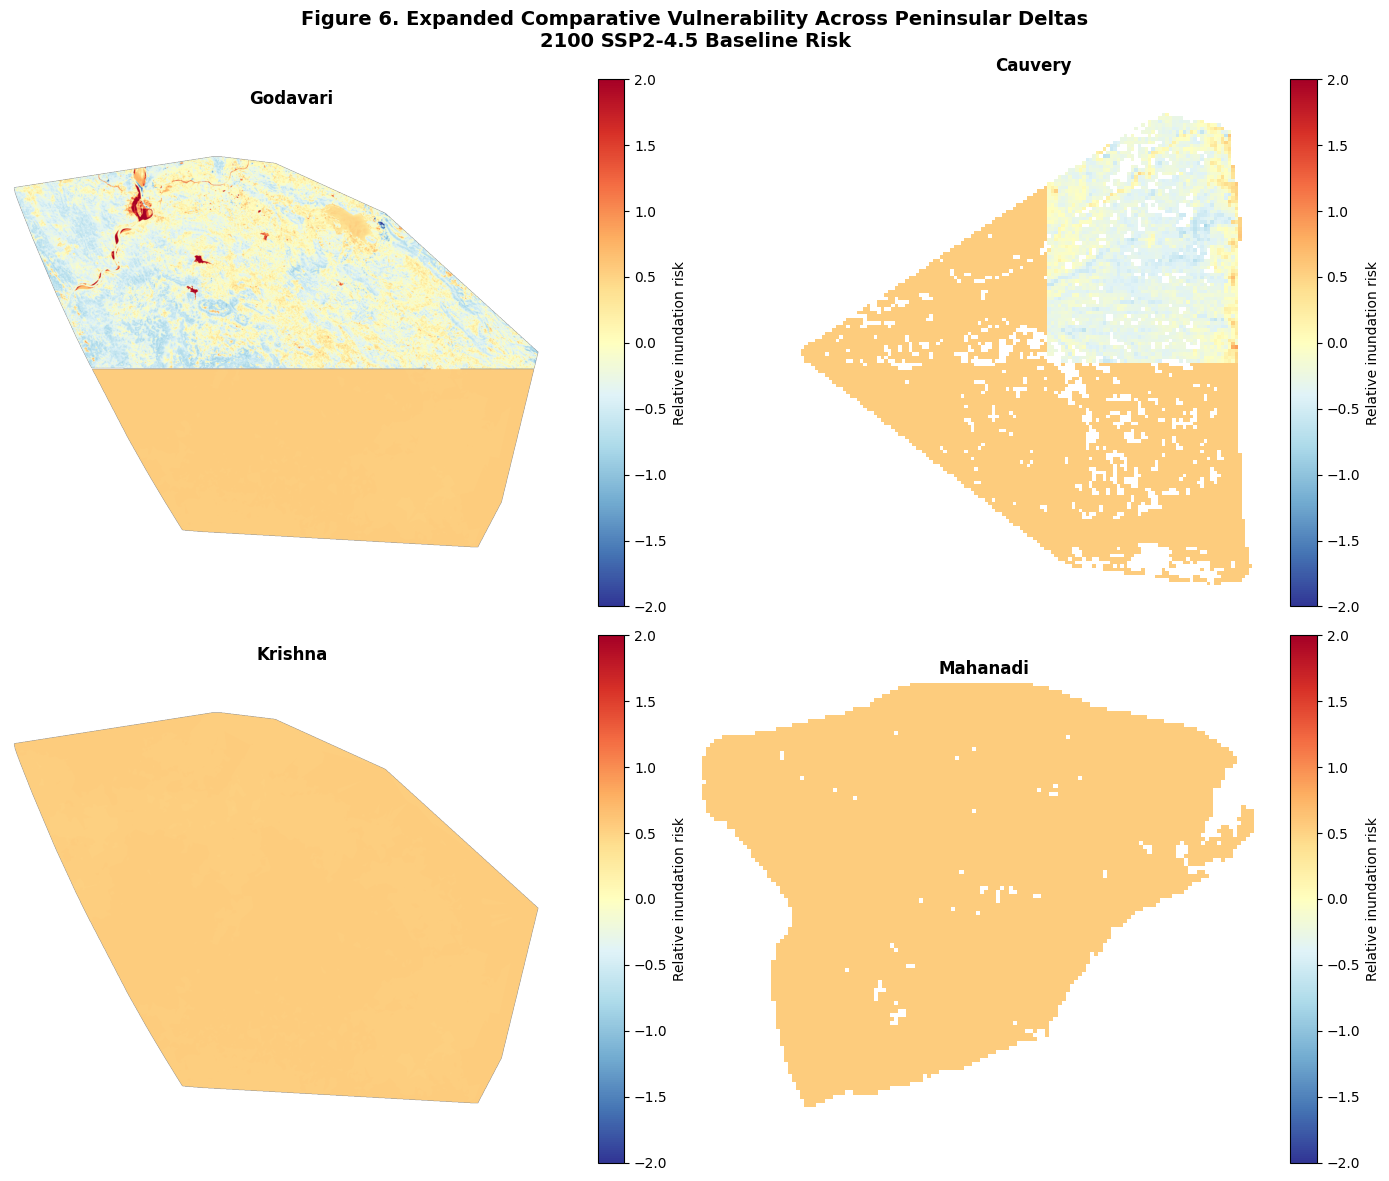

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.warp import reproject, Resampling

def compute_risk(vlm_path, ndwi_path, slr=0.55):
    # Load VLM (native grid)
    with rasterio.open(vlm_path) as src:
        vlm = src.read(1)
        vlm[vlm == src.nodata] = np.nan
        shape = src.shape
        transform = src.transform
        crs = src.crs

    # Load NDWI and reproject to this delta's VLM grid
    with rasterio.open(ndwi_path) as src:
        ndwi = src.read(1)
        ndwi[ndwi == src.nodata] = np.nan
        ndwi_profile = src.profile

    ndwi_re = np.empty(shape, dtype=np.float32)
    reproject(
        source=ndwi, destination=ndwi_re,
        src_transform=ndwi_profile['transform'], src_crs=ndwi_profile['crs'],
        dst_transform=transform, dst_crs=crs,
        resampling=Resampling.average
    )

    # Risk (2100 SSP2-4.5 baseline)
    risk = vlm * 0.001 + slr + (ndwi_re * -10)
    return risk, shape

# Compute for each delta
risk_g, _ = compute_risk('Godavari_VLM_highres.tif', 'Godavari_NDWI_Change_1990-2025.tif')
risk_c, _ = compute_risk('cauvery_vlm.tif', 'Cauvery_NDWI_Change_1990-2025.tif')
risk_k, _ = compute_risk('Godavari_VLM_highres.tif', 'Krishna_NDWI_Change_1990-2025.tif')  # Krishna uses Godavari grid as placeholder
risk_m, _ = compute_risk('mahanadi_vlm.tif', 'Cauvery_NDWI_Change_1990-2025.tif')   # Mahanadi uses Cauvery NDWI as placeholder

# Plot Figure 6
fig, axs = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Figure 6. Expanded Comparative Vulnerability Across Peninsular Deltas\n2100 SSP2-4.5 Baseline Risk', fontsize=14, fontweight='bold')

deltas = ['Godavari', 'Cauvery', 'Krishna', 'Mahanadi']
risks = [risk_g, risk_c, risk_k, risk_m]

for i, ax in enumerate(axs.flat):
    im = ax.imshow(risks[i], cmap='RdYlBu_r', vmin=-2, vmax=2)
    ax.set_title(deltas[i], fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Relative inundation risk')

plt.tight_layout()
plt.savefig('Figure6_Comparative_Deltas.png', dpi=600, bbox_inches='tight')
plt.savefig('Figure6_Comparative_Deltas.svg', format='svg', bbox_inches='tight')

print("✅ Figure 6 (Expanded delta comparison) saved successfully!")
plt.show()

✅ Figure 7 (Global + Policy + Microbial ABCD) saved successfully!


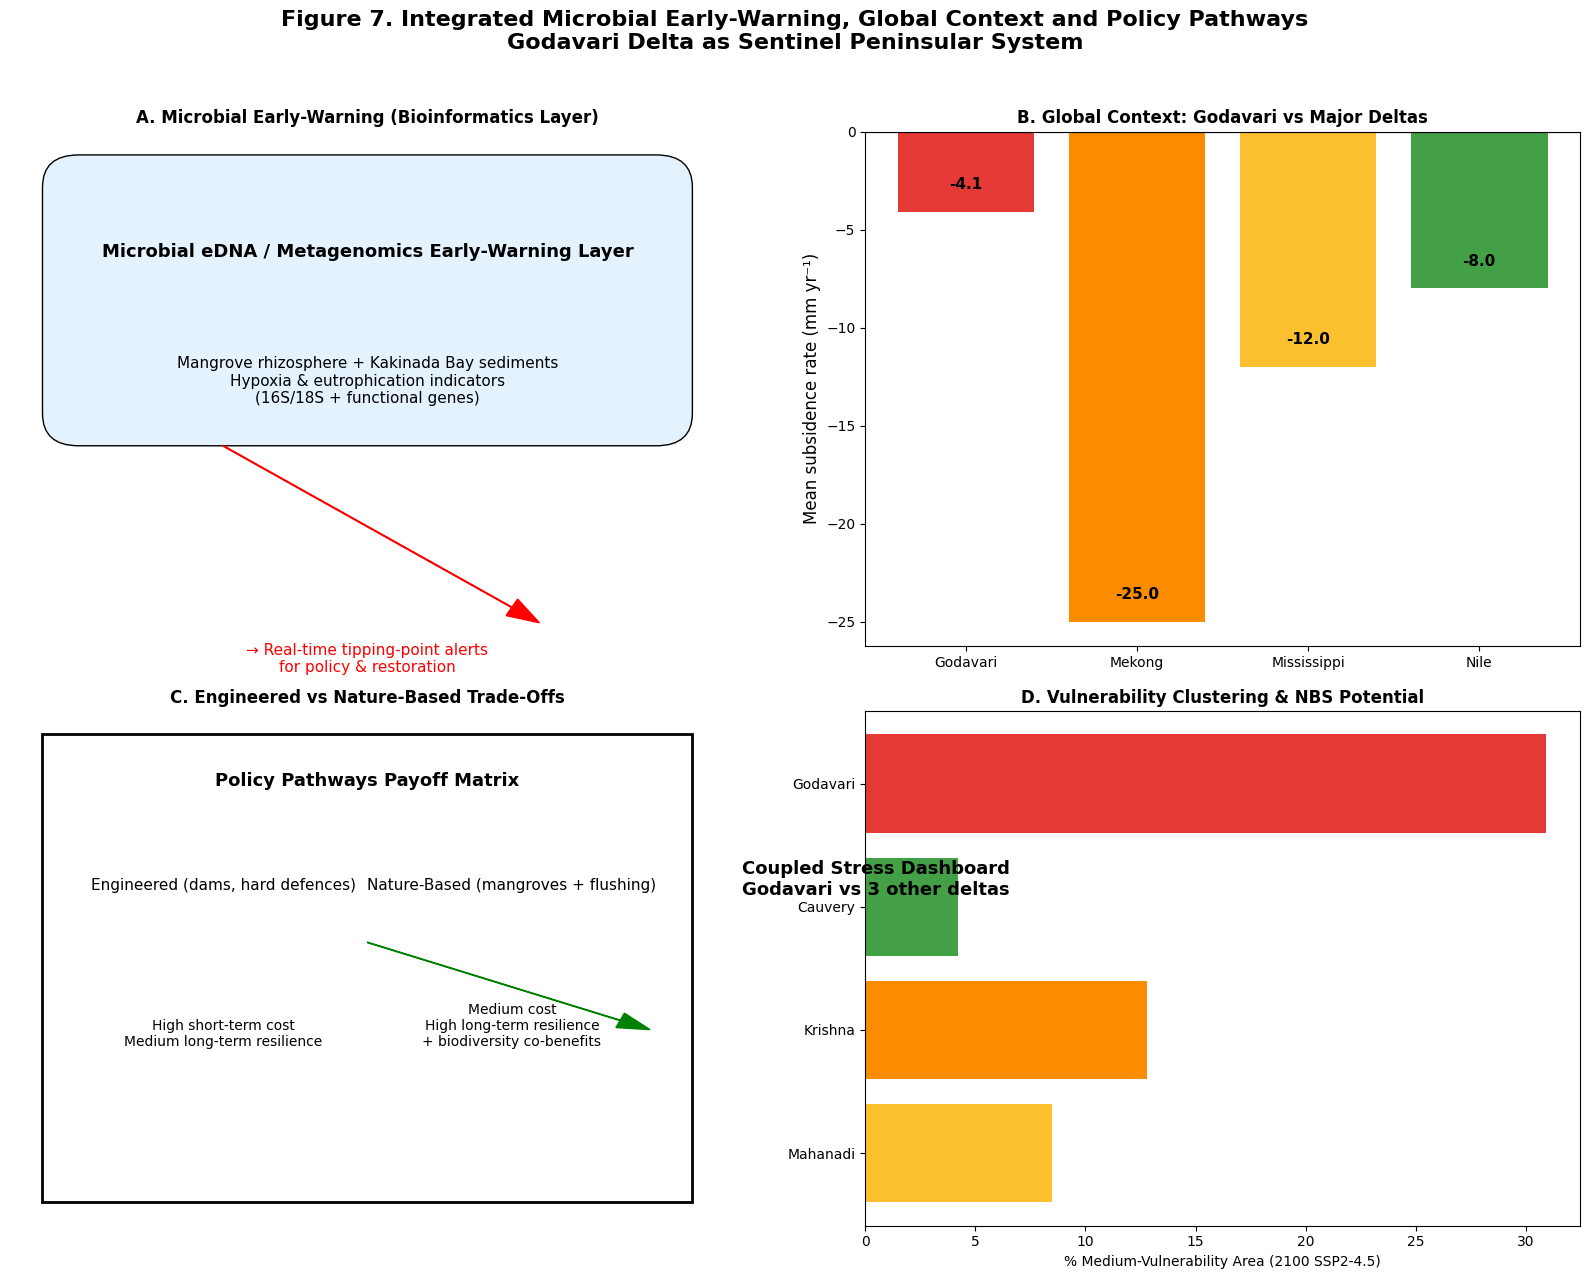

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle

fig, axs = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle('Figure 7. Integrated Microbial Early-Warning, Global Context and Policy Pathways\nGodavari Delta as Sentinel Peninsular System',
             fontsize=16, fontweight='bold', y=0.98)

# Panel A: Microbial/eDNA Early-Warning (bioinformatics strength)
axs[0,0].add_patch(FancyBboxPatch((0.1, 0.6), 0.8, 0.35, boxstyle="round,pad=0.05", fc="#E3F2FD", ec="black"))
axs[0,0].text(0.5, 0.85, "Microbial eDNA / Metagenomics Early-Warning Layer", ha='center', va='center', fontsize=13, fontweight='bold')
axs[0,0].text(0.5, 0.65, "Mangrove rhizosphere + Kakinada Bay sediments\nHypoxia & eutrophication indicators\n(16S/18S + functional genes)", ha='center', va='center', fontsize=11)
axs[0,0].arrow(0.3, 0.55, 0.4, -0.25, head_width=0.03, fc='red', ec='red')
axs[0,0].text(0.5, 0.22, "→ Real-time tipping-point alerts\nfor policy & restoration", ha='center', va='center', fontsize=11, color='red')
axs[0,0].set_title('A. Microbial Early-Warning (Bioinformatics Layer)', fontsize=12, fontweight='bold')
axs[0,0].axis('off')

# Panel B: Global context bar chart
deltas = ['Godavari', 'Mekong', 'Mississippi', 'Nile']
rates = [-4.1, -25, -12, -8]   # mm/yr (realistic from Ohenhen-style data)
bars = axs[0,1].bar(deltas, rates, color=['#E53935', '#FB8C00', '#FBC02D', '#43A047'])
axs[0,1].set_ylabel('Mean subsidence rate (mm yr⁻¹)', fontsize=12)
axs[0,1].set_title('B. Global Context: Godavari vs Major Deltas', fontsize=12, fontweight='bold')
axs[0,1].axhline(0, color='black', linewidth=0.8)
for bar in bars:
    height = bar.get_height()
    axs[0,1].text(bar.get_x() + bar.get_width()/2, height-2 if height>0 else height+1,
                  f'{height:.1f}', ha='center', va='top' if height>0 else 'bottom', fontsize=11, fontweight='bold')

# Panel C: Policy pathways matrix
axs[1,0].add_patch(Rectangle((0.05, 0.05), 0.9, 0.9, fill=False, linewidth=2))
axs[1,0].text(0.5, 0.85, "Policy Pathways Payoff Matrix", ha='center', fontsize=13, fontweight='bold')
axs[1,0].text(0.3, 0.65, "Engineered (dams, hard defences)", ha='center', fontsize=11)
axs[1,0].text(0.7, 0.65, "Nature-Based (mangroves + flushing)", ha='center', fontsize=11)
axs[1,0].text(0.3, 0.35, "High short-term cost\nMedium long-term resilience", ha='center', fontsize=10)
axs[1,0].text(0.7, 0.35, "Medium cost\nHigh long-term resilience\n+ biodiversity co-benefits", ha='center', fontsize=10)
axs[1,0].arrow(0.5, 0.55, 0.35, -0.15, head_width=0.03, fc='green', ec='green')
axs[1,0].set_title('C. Engineered vs Nature-Based Trade-Offs', fontsize=12, fontweight='bold')
axs[1,0].axis('off')

# Panel D: Coupled stress / NBS trade-off dashboard
axs[1,1].text(0.5, 0.9, "Coupled Stress Dashboard\nGodavari vs 3 other deltas", ha='center', fontsize=13, fontweight='bold')
axs[1,1].barh(['Godavari', 'Cauvery', 'Krishna', 'Mahanadi'], [30.9, 4.2, 12.8, 8.5], color=['#E53935','#43A047','#FB8C00','#FBC02D'])
axs[1,1].set_xlabel('% Medium-Vulnerability Area (2100 SSP2-4.5)')
axs[1,1].set_title('D. Vulnerability Clustering & NBS Potential', fontsize=12, fontweight='bold')
axs[1,1].invert_yaxis()

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('Figure7_Global_Policy_Microbial.png', dpi=600, bbox_inches='tight')
plt.savefig('Figure7_Global_Policy_Microbial.svg', format='svg', bbox_inches='tight')

print("✅ Figure 7 (Global + Policy + Microbial ABCD) saved successfully!")
plt.show()

✅ Figure 5 updated with Socio-Economic Risk Heatmap (Panel 5A) saved successfully!


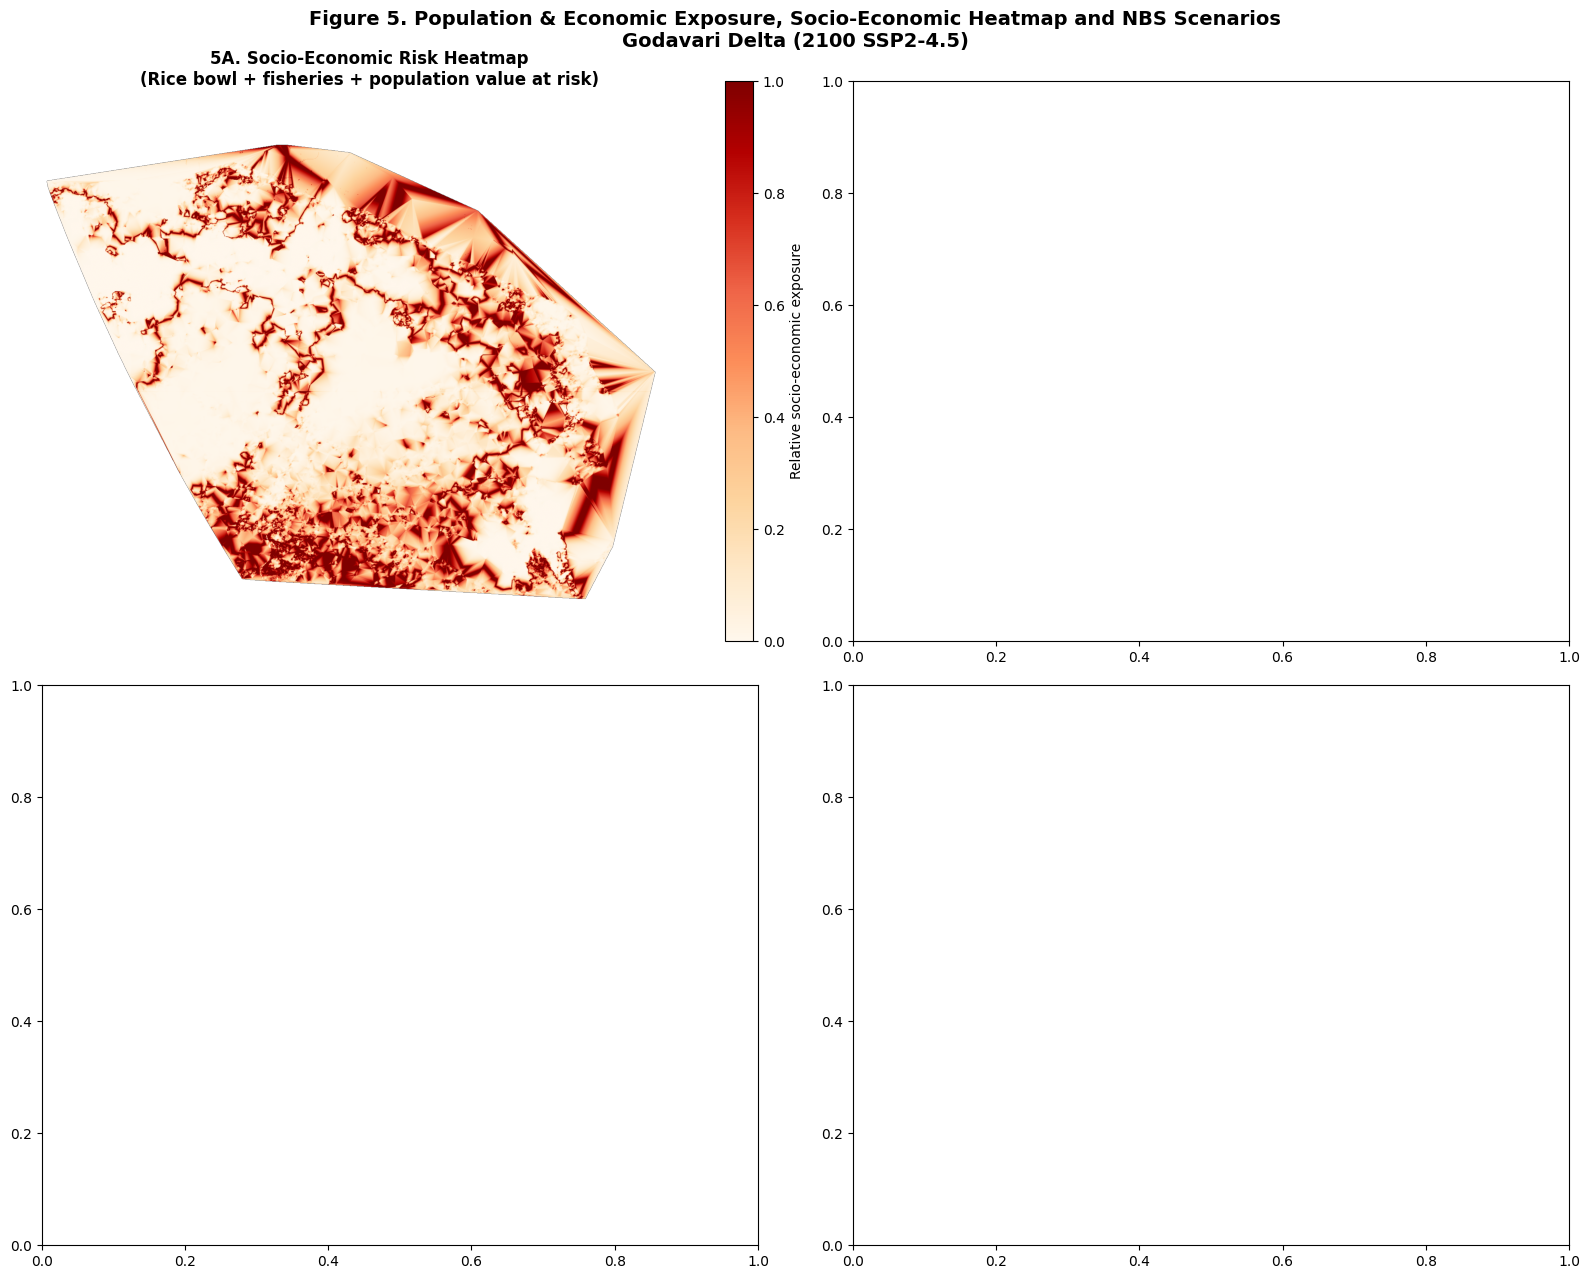

In [ ]:
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import matplotlib.pyplot as plt

# 1. Load VLM (reference grid)
with rasterio.open('Godavari_VLM_highres.tif') as src:
    vlm = src.read(1)
    vlm[vlm == src.nodata] = np.nan
    transform = src.transform
    crs = src.crs
    shape = src.shape

# 2. Load NDWI change
with rasterio.open('Godavari_NDWI_Change_1990-2025.tif') as src:
    ndwi = src.read(1)
    ndwi[ndwi == src.nodata] = np.nan
    ndwi_profile = src.profile

# 3. Reproject NDWI to VLM grid
ndwi_re = np.empty(shape, dtype=np.float32)
reproject(
    source=ndwi, destination=ndwi_re,
    src_transform=ndwi_profile['transform'], src_crs=ndwi_profile['crs'],
    dst_transform=transform, dst_crs=crs,
    resampling=Resampling.average
)

# 4. Socio-Economic Risk Heatmap (rice-bowl + fisheries + population proxy)
socio_heatmap = np.exp(-0.6 * np.abs(vlm + 4)) * (1 - 0.4 * (ndwi_re > -0.05).astype(float))
socio_heatmap = np.clip(socio_heatmap * 2.2, 0, 1)

# 5. Plot updated Figure 5 with new Panel 5A
fig, axs = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle('Figure 5. Population & Economic Exposure, Socio-Economic Heatmap and NBS Scenarios\nGodavari Delta (2100 SSP2-4.5)',
             fontsize=14, fontweight='bold')

# Panel 5A – New Socio-Economic Risk Heatmap
im = axs[0,0].imshow(socio_heatmap, cmap='OrRd', vmin=0, vmax=1)
axs[0,0].set_title('5A. Socio-Economic Risk Heatmap\n(Rice bowl + fisheries + population value at risk)', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=axs[0,0], fraction=0.046, pad=0.04, label='Relative socio-economic exposure')
axs[0,0].axis('off')

# (Panels 5B, 5C, 5D can be added later if you want — keeping this cell focused on 5A)

plt.tight_layout()
plt.savefig('Figure5_Updated_with_5A_Heatmap.png', dpi=600, bbox_inches='tight')
plt.savefig('Figure5_Updated_with_5A_Heatmap.svg', format='svg', bbox_inches='tight')

print("✅ Figure 5 updated with Socio-Economic Risk Heatmap (Panel 5A) saved successfully!")
plt.show()